# Part1: Basic analysis of the HGSC dataset

# Package loading and path setting

In [1]:
import sys, os
working_dir = "D:/CellFlowMap/SpiderNet_proj/SpiderNet_proj/"
sys.path.append("working_dir")
import os
from SpiderNet.utils import *

# Hyperparameter Setup

In [2]:

# Version
Version_cur = "V1"

# Factorization mode
Factor_mode = 'cell_class'  # options: 'cell_class', 'NMF'
dim_intri = 25 if Factor_mode == "NMF" else None

# Environmental dimension
dim_envir = 15   # examples: 8, 10, 12, 20, 30, None

# Meta-interaction aggregation threshold
MIlevel_agg_threshold = 0.6     # typical range: 0.4–0.7


# File Path Setup

In [3]:
# Base directories
data_path_main = "D:/CellFlowMap/HGSC/Data/"
save_path_main = data_path_main.replace("Data/", "Results/")

# Current run directory (versioned)
save_path_main_cur = os.path.join(save_path_main, Version_cur)
os.makedirs(save_path_main_cur, exist_ok=True)

# Define subdirectory name pattern
subset_tag = ""
result_tag = f"SpiderNet_Result_Mode_{Factor_mode}_selfsetdim{dim_envir}{subset_tag}"

# Define output paths
file_savepath_main = os.path.join(save_path_main_cur, result_tag)
if not file_savepath_main.endswith(os.sep):
    file_savepath_main += os.sep

# Meta-interaction correlation analysis

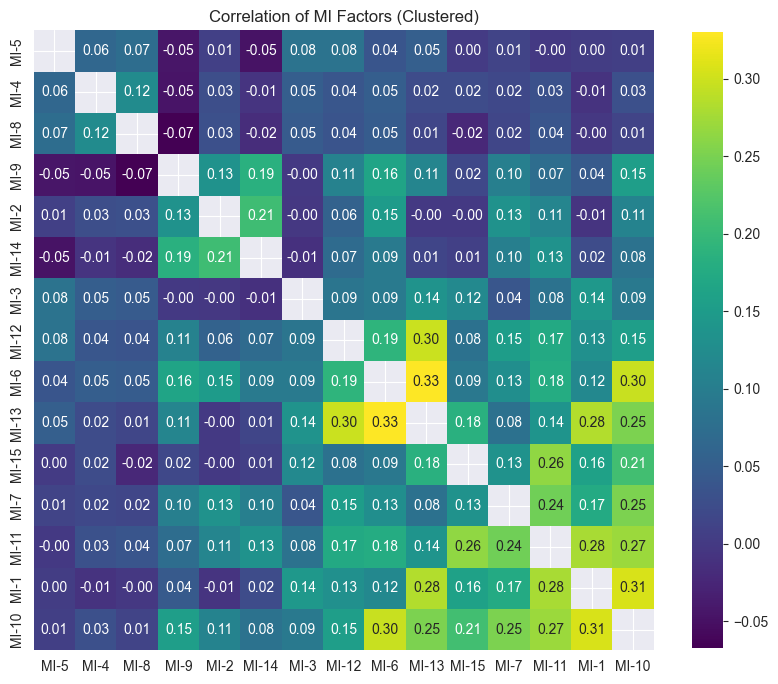

✅ Saved heatmap to D:/CellFlowMap/HGSC/Results/V1\SpiderNet_Result_Mode_cell_class_selfsetdim15\MI_correlation_heatmap_clustered.png


In [4]:
from SpiderNet.MI_correlation_analysis import run_analysis

run_analysis(file_savepath_main,  file_savepath_main + "Factor_envir_use.npy", show=True)

#  LR Loading enrichment analysis

BMP: 4 LR pairs
CDH1: 1 LR pairs
COLLAGEN: 63 LR pairs
EPHA: 2 LR pairs
EPHB: 10 LR pairs
FGF: 10 LR pairs
FN1: 8 LR pairs
MHC-I: 8 LR pairs
MHC-II: 7 LR pairs
IGF: 5 LR pairs
ACTIVIN: 1 LR pairs
GALECTIN: 1 LR pairs
MIF: 1 LR pairs
SPP1: 7 LR pairs
THBS: 8 LR pairs
LIGHT: 2 LR pairs
VTN: 2 LR pairs
WNT: 31 LR pairs
ncWNT: 14 LR pairs


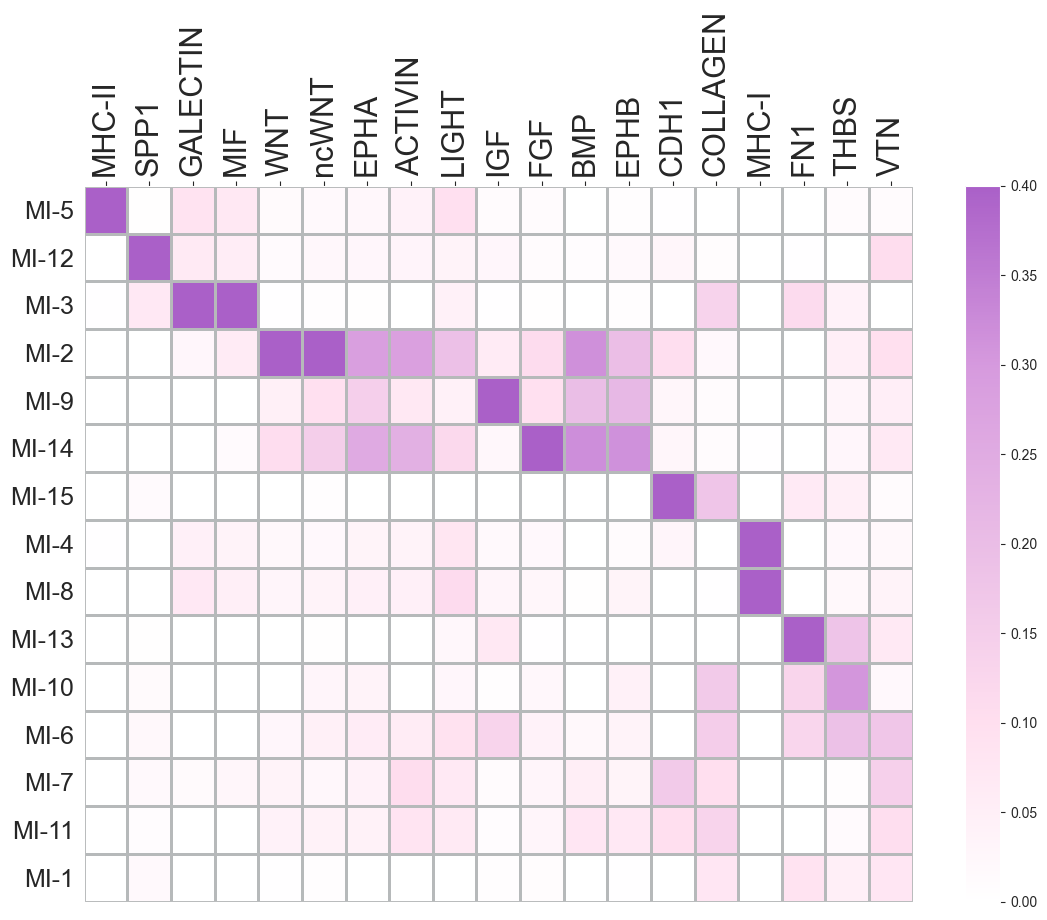

In [5]:
from SpiderNet.Loading_LR_enrichment_analysis import run_analysis

run_analysis(
    loading_LR_use_path = file_savepath_main + "loading_LR_use.npy",
    lr_list_path = file_savepath_main + "LR_list.pkl",
    lr_list_cellchatdb_path = file_savepath_main + "LR_list_cellchatdb.pkl",
    lr_meta_cellchatdb_path = file_savepath_main + "LR_meta_cellchatdb.pkl",
    Factor_envir_use_path = file_savepath_main + "Factor_envir_use.npy",
    file_savepath_main = file_savepath_main,
    show = True
)


In [6]:
LR_list_merge_path = file_savepath_main + 'LR_list_merge.pkl'
LR_list_merge = pd.read_pickle(LR_list_merge_path)
loading_LR_use_path = file_savepath_main + "loading_LR_use.npy"
loading_LR_use = np.load(loading_LR_use_path)
loading_LR_use
loading_LR_use_df = pd.DataFrame(loading_LR_use, index=["MI" + str(i + 1) for i in range(loading_LR_use.shape[0])],
                                 columns=LR_list_merge)
##Save the loading_LR_use_df as csv
loading_LR_use_df_path = file_savepath_main + "loading_LR_use.csv"
loading_LR_use_df.to_csv(loading_LR_use_df_path, index=True)

# Celltype pair enrichment for the Meta-Interactions

D:\CellFlowMap\SpiderNet_proj\SpiderNet_proj\.venv\Lib\site-packages\scanpy\_utils\__init__.py:35: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
D:\CellFlowMap\SpiderNet_proj\SpiderNet_proj\.venv\Lib\site-packages\scanpy\__init__.py:24: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
D:\CellFlowMap\SpiderNet_proj\SpiderNet_proj\.venv\Lib\site-packages\scanpy\readwrite.py:15: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):


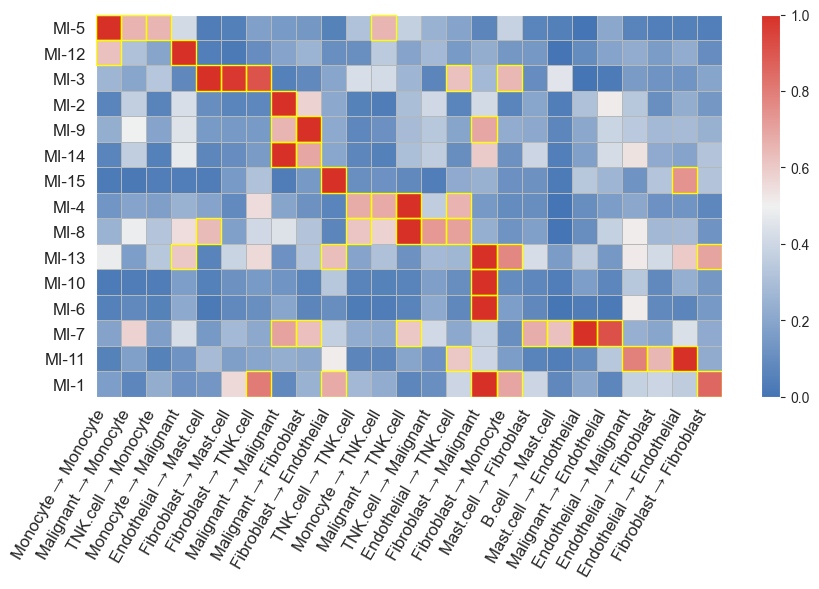

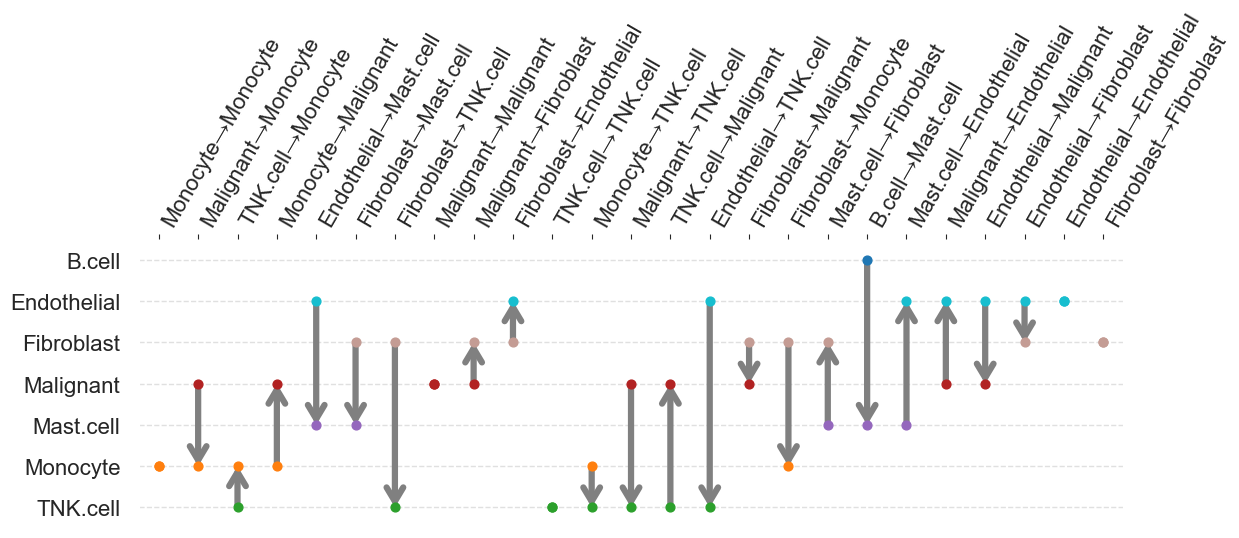

D:\CellFlowMap\SpiderNet_proj\SpiderNet_proj\SpiderNet\MI_Celltypepair_enrichment_analysis.py:738: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.2467326670885086' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  Avg_MI_cellclass_pair_merge_zscored_ctagg_sender.iloc[idx, :] = list(
D:\CellFlowMap\SpiderNet_proj\SpiderNet_proj\SpiderNet\MI_Celltypepair_enrichment_analysis.py:738: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.08698076009750366' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  Avg_MI_cellclass_pair_merge_zscored_ctagg_sender.iloc[idx, :] = list(
D:\CellFlowMap\SpiderNet_proj\SpiderNet_proj\SpiderNet\MI_Celltypepair_enrichment_analysis.py:738: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an e

{'Avg_MI_cellclass_pair_merge_use_csv': 'D:/CellFlowMap/HGSC/Results/V1\\SpiderNet_Result_Mode_cell_class_selfsetdim15\\Avg_MI_cellclass_pair_merge_use.csv',
 'Avg_MI_cellclass_pair_png': 'D:/CellFlowMap/HGSC/Results/V1\\SpiderNet_Result_Mode_cell_class_selfsetdim15\\Avg_MI_cellclass_pair.png',
 'Avg_MI_cellclass_pair_onlymalignant_png': 'D:/CellFlowMap/HGSC/Results/V1\\SpiderNet_Result_Mode_cell_class_selfsetdim15\\Avg_MI_cellclass_pair_onlymalignant_highlight.png',
 'Sender_vs_Receiver_scatter_png': 'D:/CellFlowMap/HGSC/Results/V1\\SpiderNet_Result_Mode_cell_class_selfsetdim15\\Sender_vs_Receiver_MI_Strength.png',
 'Celltype_pair_example_png': 'D:/CellFlowMap/HGSC/Results/V1\\SpiderNet_Result_Mode_cell_class_selfsetdim15\\Celltype_pair_example.png',
 'Agg_heatmap_png': 'D:/CellFlowMap/HGSC/Results/V1\\SpiderNet_Result_Mode_cell_class_selfsetdim15\\Avg_MI_cellclass_pair_agg.png',
 'Site_dotplot_png': 'D:/CellFlowMap/HGSC/Results/V1\\SpiderNet_Result_Mode_cell_class_selfsetdim15\\Avg_M

In [7]:
from SpiderNet.MI_Celltypepair_enrichment_analysis import run_analysis

run_analysis(
    SpiderNet_data_pyg_list_path = file_savepath_main + "SpiderNet_data_pyg_list.pkl",
    Factor_envir_use_path = file_savepath_main + "Factor_envir_use.npy",
    file_savepath_main = file_savepath_main,
    metadata_sample_path = file_savepath_main + "metadata_sample.csv",
    LR_loading_pathway_path = file_savepath_main + "LR_loading_pathway.csv",
    dim_envir = dim_envir,
    MIlevel_agg_threshold = MIlevel_agg_threshold,
    batch_cell_unique_path = file_savepath_main + "batch_cell_unique.pkl",
    adata_list_path = file_savepath_main + "adata_list.pkl",
    adata_copy_path = file_savepath_main + "adata_all.h5ad",
    show = True
)
